Redémarrage env (Python 3.13.5)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import os


In [3]:
Acteurs = pd.read_csv("name_basics.tsv.gz", sep="\t", compression="gzip", nrows=2000000)
Films = pd.read_csv("title.basics.tsv.gz", sep="\t", compression="gzip", nrows=2000000)
Principals = pd.read_csv("title.principals.tsv.gz",sep="\t",compression="gzip",na_values="\\N",nrows=2000000)
Ratings = pd.read_csv("title.ratings.tsv.gz",sep="\t",compression="gzip",na_values="\\N",nrows=2000000)


In [4]:
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# 1) Chargement optimisé
# -----------------------------
N = 2_000_000

names = pd.read_csv("name_basics.tsv.gz", sep="\t", compression="gzip", na_values="\\N", nrows=N)

titles = pd.read_csv("title.basics.tsv.gz", sep="\t", compression="gzip", na_values="\\N", nrows=N)

# Retirer les contenus adultes
titles = titles[titles["isAdult"] == 0]

# Garder uniquement les colonnes utiles (inclut GENRES)
titles = titles[["tconst", "primaryTitle", "titleType", "startYear", "genres"]]

principals = pd.read_csv("title.principals.tsv.gz", sep="\t", compression="gzip", na_values="\\N", nrows=N)
ratings = pd.read_csv("title.ratings.tsv.gz", sep="\t", compression="gzip", na_values="\\N", nrows=N)

# -----------------------------
# 2) Filtrer les vrais acteurs
# -----------------------------

# Nettoyage et découpage des professions
names["primaryProfession"] = names["primaryProfession"].fillna("").str.split(",")

# 1) Garder uniquement ceux dont la profession principale est actor/actress
names = names[
    names["primaryProfession"].apply(lambda profs: len(profs) > 0 and profs[0] in ["actor", "actress"])
]

# 2) Filtrer les rôles dans title.principals : garder uniquement actor/actress
principals = principals[principals["category"].isin(["actor", "actress"])]

# 3) Nettoyage des noms (éviter les prénoms seuls, pseudos, etc.)
names = names[names["primaryName"].fillna("").str.contains(" ")]

# -----------------------------
# 3) Jointure ACTEURS × TITRES
# -----------------------------
acteurs_titres = principals.merge(
    names[["nconst", "primaryName", "birthYear"]],
    on="nconst",
    how="inner"
).merge(
    titles,   # <-- contient maintenant genres
    on="tconst",
    how="inner"
).merge(
    ratings[["tconst", "averageRating", "numVotes"]],
    on="tconst",
    how="left"
)

# -----------------------------
# 4) Nettoyage des années
# -----------------------------
acteurs_titres["startYear"] = pd.to_numeric(acteurs_titres["startYear"], errors="coerce")
acteurs_titres["birthYear"] = pd.to_numeric(acteurs_titres["birthYear"], errors="coerce")

# -----------------------------
# 5) Décennie (robuste)
# -----------------------------
acteurs_titres["decade"] = (acteurs_titres["startYear"] // 10) * 10
acteurs_titres.loc[acteurs_titres["decade"] < 1880, "decade"] = np.nan

# -----------------------------
# 6) Catégorie simplifiée
# -----------------------------
mapping_categorie = {
    "movie": "Film",
    "tvMovie": "Téléfilm",
    "tvSeries": "Série"
}

acteurs_titres["categorie"] = acteurs_titres["titleType"].map(mapping_categorie)

# -----------------------------
# 7) Colonnes utiles
# -----------------------------
colonnes_utiles = [
    "nconst", "primaryName", "birthYear",
    "tconst", "primaryTitle", "titleType", "categorie",
    "genres",                      # <-- AJOUT ICI
    "startYear", "decade",
    "averageRating", "numVotes"
]

acteurs_titres = acteurs_titres[colonnes_utiles]

# -----------------------------
# 8) Ordonner les types de titres
# -----------------------------
ordre_types = ["movie", "tvMovie", "tvSeries"]

acteurs_titres["titleType"] = pd.Categorical(
    acteurs_titres["titleType"],
    categories=ordre_types,
    ordered=True
)

# -----------------------------
# 9) Tri final
# -----------------------------
acteurs_titres = acteurs_titres.sort_values(
    by=["primaryName", "titleType", "startYear"]
)

# -----------------------------
# 10) Analyse finale
# -----------------------------
since_year = 1920
birth_min = 1940
birth_max = 2026
top_n_global = 3000
top_n_per_actor = None

films = acteurs_titres.copy()
films = films[films["startYear"].ge(since_year)]

if birth_min is not None:
    films = films[films["birthYear"].ge(birth_min)]
if birth_max is not None:
    films = films[films["birthYear"].le(birth_max)]

films = films.sort_values(["startYear","averageRating","numVotes"], ascending=[False,False,False])
top_global = films.drop_duplicates("tconst").head(top_n_global).reset_index(drop=True)

top_par_acteur = (
    films.sort_values(["primaryName","startYear","averageRating","numVotes"], ascending=[True,False,False,False])
         .groupby("primaryName", as_index=False)
         .head(top_n_per_actor)
         .reset_index(drop=True)
)

cols = [
    "primaryName","birthYear","tconst","primaryTitle",
    "categorie","genres","startYear","decade","averageRating","numVotes"
]

display(films[cols])


,primaryName,birthYear,tconst,primaryTitle,categorie,genres,startYear,decade,averageRating,numVotes
824017,Karin Anselm,1940.0,tt0111463,Totschweigen,Film,"Documentary,Drama",2026.0,2020.0,8.0,24.0
824018,Kornelia Boje,1942.0,tt0111463,Totschweigen,Film,"Documentary,Drama",2026.0,2020.0,8.0,24.0
839657,Dee Wallace,1948.0,tt0113735,The Magic 7,Série,"Adventure,Animation,Family",2026.0,2020.0,NaN,NaN
839651,Demi Moore,1962.0,tt0113735,The Magic 7,Série,"Adventure,Animation,Family",2026.0,2020.0,NaN,NaN
839652,Jennifer Love Hewitt,1979.0,tt0113735,The Magic 7,Série,"Adventure,Animation,Family",2026.0,2020.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
220789,Nancy Louise King,1940.0,tt0033181,Trailing Double Trouble,Film,"Drama,Music,Western",1940.0,1940.0,5.6,80.0
196678,Ashalata Wabgaonkar,1941.0,tt0030305,Jwala,Film,NaN,1938.0,1930.0,NaN,NaN
176734,Richard Flinck,1961.0,tt0027853,The Trouble with Money,Film,"Comedy,Drama",1936.0,1930.0,6.6,203.0
152536,David Timson,1950.0,tt0024777,Wings Over Everest,NaN,"Documentary,Short",1934.0,1930.0,6.0,158.0


In [5]:
since_year = 1920
birth_min = 1940
birth_max = 2026
top_n_global = 3000
top_n_per_actor = None


In [96]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# 1) Préparation des données
# ------------------------------------------------------------

# Compter les présences par acteur et par type
presence_type = (
    films
    .groupby(["primaryName", "categorie"])
    .size()
    .reset_index(name="nb")
)

# ------------------------------------------------------------
# 2) Fonction pour générer le Top N dynamique
# ------------------------------------------------------------
def compute_topN(df, N):
    top_acteurs = (
        df.groupby("primaryName")["nb"]
        .sum()
        .sort_values(ascending=False)
        .head(N)
        .index
    )
    return df[df["primaryName"].isin(top_acteurs)]

# ------------------------------------------------------------
# 3) Fonction d'affichage du graphique
# ------------------------------------------------------------
def plot_presence(df, title):
    fig = px.bar(
        df,
        x="nb",
        y="primaryName",
        color="categorie",
        orientation="h",
        title=title,
        color_discrete_map={
            "Film": "#440154",
            "Téléfilm": "#31688e",
            "Série": "#35b779"
        }
    )

    fig.update_layout(
        height=800,
        barmode="stack",
        xaxis_title="Nombre de présences",
        yaxis_title="Acteurs",
        margin=dict(l=200, r=40, t=70, b=60)
    )

    fig.show()

# ------------------------------------------------------------
# 4) Widgets : menu déroulant + slider Top N
# ------------------------------------------------------------
dropdown_cat = widgets.Dropdown(
    options=["Tous", "Film", "Téléfilm", "Série"],
    value="Tous",
    description="Catégorie :"
)

slider_top = widgets.IntSlider(
    value=20,
    min=5,
    max=50,
    step=5,
    description="Top N :",
    continuous_update=False
)

output = widgets.Output()

# ------------------------------------------------------------
# 5) Fonction dynamique
# ------------------------------------------------------------
def update_graph(change):
    with output:
        clear_output(wait=True)

        # Filtre catégorie
        if dropdown_cat.value == "Tous":
            df_filtered = presence_type.copy()
        else:
            df_filtered = presence_type[presence_type["categorie"] == dropdown_cat.value]

        # Top N dynamique
        df_top = compute_topN(df_filtered, slider_top.value)

        # Titre dynamique
        title = f"Présences par type — Top {slider_top.value} ({dropdown_cat.value})"

        # Affichage
        plot_presence(df_top, title)

dropdown_cat.observe(update_graph, names="value")
slider_top.observe(update_graph, names="value")

# ------------------------------------------------------------
# 6) Affichage final
# ------------------------------------------------------------
display(dropdown_cat, slider_top, output)
update_graph(None)


Dropdown(description='Catégorie :', options=('Tous', 'Film', 'Téléfilm', 'Série'), value='Tous')

IntSlider(value=20, continuous_update=False, description='Top N :', max=50, min=5, step=5)

Output()

In [7]:
# -----------------------------
# Ratio présence / popularité PAR DÉCENNIE
# -----------------------------

# 1) Nombre de titres par acteur et par décennie
presence_dec = (
    films
    .groupby(["decade", "primaryName"])["tconst"]
    .nunique()
    .reset_index(name="nb_titres")
)

# 2) Popularité totale (votes) par acteur et par décennie
popularite_dec = (
    films
    .groupby(["decade", "primaryName"])["numVotes"]
    .sum()
    .reset_index(name="total_votes")
)

# 3) Fusion
ratio_dec = presence_dec.merge(popularite_dec, on=["decade", "primaryName"], how="left")

# 4) Ratio
ratio_dec["ratio_presence_popularite"] = (
    ratio_dec["nb_titres"] / ratio_dec["total_votes"]
)

# 5) Nettoyage
ratio_dec = ratio_dec.replace([np.inf, -np.inf], np.nan).dropna(subset=["ratio_presence_popularite"])

# 6) Top 30 par décennie
ratio_top_dec = (
    ratio_dec
    .sort_values(["decade", "ratio_presence_popularite"], ascending=[True, False])
    .groupby("decade")
    .head(30)
    .reset_index(drop=True)
)

ratio_top_dec

import plotly.express as px
import numpy as np

# Décennies triées
decades = sorted(ratio_top_dec["decade"].unique())

# Palette Viridis ordonnée
viridis = px.colors.sequential.Viridis
n = len(decades)
palette = [viridis[int(i)] for i in np.linspace(0, len(viridis)-1, n)]

# Mapping décennie → couleur
color_map = {dec: palette[i] for i, dec in enumerate(decades)}

# Colonne texte pour la légende
ratio_top_dec["decade_str"] = ratio_top_dec["decade"].astype(str)

# Valeur max globale pour fixer l'échelle
max_global = ratio_top_dec["ratio_presence_popularite"].max()

# Graphique dynamique
fig = px.bar(
    ratio_top_dec,
    x="ratio_presence_popularite",
    y="primaryName",
    color="decade_str",
    orientation="h",
    animation_frame="decade",
    title="Ratio Présence / Popularité par Décennie",
    color_discrete_map=color_map,
    height=900,
    range_x=[0, max_global]
)

# Top en haut
fig.update_yaxes(autorange="reversed")

# Mise en forme premium
fig.update_layout(
    title_font_size=22,
    xaxis_title="Ratio présence / popularité",
    yaxis_title="Acteur",
    legend_title="Décennie",
    bargap=0.25,
    transition={'duration': 0}
)

# Slider propre
fig.layout.sliders[0].currentvalue.prefix = "Décennie : "

# ❌ Supprimer Play/Pause → slider manuel uniquement
fig.update_layout(updatemenus=[])

fig.show()

fig.write_image("plots/graphique_Ratio présence_popularité.png")

In [8]:
# -----------------------------
# Âge moyen des acteurs selon popularité (Top 10 + filtre genre)
# -----------------------------

# 1) Calcul de l'âge au moment du film
films["age"] = films["startYear"] - films["birthYear"]

# Nettoyage : retirer âges impossibles
films = films[(films["age"] > 10) & (films["age"] < 100)]

# 2) Explosion des genres (car "Action,Drama" doit devenir 2 lignes)
films_genres = films.assign(
    genre=films["genres"].str.split(",")
).explode("genre")

# 3) Popularité par genre = somme des votes
popularite_genre = (
    films_genres
    .groupby("genre")["numVotes"]
    .sum()
    .reset_index(name="total_votes")
)

# 4) Top 10 genres les plus populaires
top10_genres = popularite_genre.sort_values("total_votes", ascending=False).head(10)["genre"]

# 5) Filtrer les films sur ces 10 genres
films_top_genres = films_genres[films_genres["genre"].isin(top10_genres)]

# 6) Calcul de l'âge moyen par genre
age_moyen_genre = (
    films_top_genres
    .groupby("genre")["age"]
    .mean()
    .reset_index(name="age_moyen")
    
)
import plotly.express as px

fig = px.bar(
    age_moyen_genre.sort_values("age_moyen"),
    x="age_moyen",
    y="genre",
    orientation="h",
    title="Âge moyen des acteurs selon popularité (Top 10 genres)",
    labels={
        "age_moyen": "Âge moyen",
        "genre": "Genre"
    },
    color="age_moyen",
    color_continuous_scale="Viridis"
)

fig.update_layout(height=700)

fig.show()


fig.write_image("plots/âge_moyen_acteurs_pop.png")

In [9]:
#✅ 1) Top 10 par décennie — MOVIE

top10_movie = (
    films[films["titleType"] == "movie"]
    .groupby(["decade", "primaryName"])["tconst"]
    .nunique()
    .reset_index(name="nb_titres")
    .sort_values(["decade", "nb_titres"], ascending=[True, False])
    .groupby("decade")
    .head(10)
    .reset_index(drop=True)
)

top10_movie

import plotly.express as px
import numpy as np

# Décennies triées
decades = sorted(top10_movie["decade"].unique())

# Palette Viridis ordonnée
viridis = px.colors.sequential.Viridis
n = len(decades)
palette = [viridis[int(i)] for i in np.linspace(0, len(viridis)-1, n)]

# Mapping décennie → couleur
color_map = {dec: palette[i] for i, dec in enumerate(decades)}

# Colonne texte pour la légende
top10_movie["decade_str"] = top10_movie["decade"].astype(str)

# Valeur max globale pour fixer l'échelle
max_global = top10_movie["nb_titres"].max()

# Graphique dynamique
fig = px.bar(
    top10_movie,
    x="nb_titres",
    y="primaryName",
    color="decade_str",
    orientation="h",
    animation_frame="decade",
    title="Top 10 acteurs les plus prolifiques par décennie — Films",
    color_discrete_map=color_map,
    height=850,
    range_x=[0, max_global]   # <-- ÉCHELLE FIXE
)

# Top en haut
fig.update_yaxes(autorange="reversed")

# Mise en forme premium
fig.update_layout(
    title_font_size=22,
    xaxis_title="Nombre de titres",
    yaxis_title="Acteurs",
    legend_title="Décennie",
    bargap=0.25,
    transition={'duration': 300}
)

# Slider propre
fig.layout.sliders[0].currentvalue.prefix = "Décennie : "

# ❌ SUPPRIMER les boutons Play/Pause
fig.update_layout(
    updatemenus=[]   # <-- plus de lecture automatique
)

fig.show()

fig.write_image("TOP_10_acteurs_décade.png")

In [10]:
# Top 10 par décennie — TV MOVIE
top10_tv_movie = (
    top_global[top_global["titleType"] == "tvMovie"]
    .groupby(["decade", "primaryName"])["tconst"]
    .nunique()
    .reset_index(name="nb_titres")
    .sort_values(["decade", "nb_titres"], ascending=[True, False])
    .groupby("decade")
    .head(10)
    .reset_index(drop=True)
)

top10_tv_movie

import plotly.express as px
import numpy as np

# Décennies triées
decades = sorted(top10_tv_movie["decade"].unique())

# Palette Viridis ordonnée
viridis = px.colors.sequential.Viridis
n = len(decades)
palette = [viridis[int(i)] for i in np.linspace(0, len(viridis)-1, n)]

# Mapping décennie → couleur
color_map = {dec: palette[i] for i, dec in enumerate(decades)}

# Colonne texte pour la légende
top10_tv_movie["decade_str"] = top10_tv_movie["decade"].astype(str)

# Valeur max globale pour fixer l'échelle
max_global = top10_tv_movie["nb_titres"].max()

# Graphique dynamique
fig = px.bar(
    top10_tv_movie,
    x="nb_titres",
    y="primaryName",
    color="decade_str",          # légende correcte
    orientation="h",
    animation_frame="decade",    # slider manuel
    title="Top 10 acteurs les plus prolifiques par décennie — TV Movies",
    color_discrete_map=color_map,
    height=850,
    range_x=[0, max_global]      # échelle fixe pour garder les disparités
)

# Top en haut
fig.update_yaxes(autorange="reversed")

# Mise en forme premium
fig.update_layout(
    title_font_size=22,
    xaxis_title="Nombre de titres",
    yaxis_title="Acteurs",
    legend_title="Décennie",
    bargap=0.25,
    transition={'duration': 0}   # pas d’animation automatique
)

# Slider propre
fig.layout.sliders[0].currentvalue.prefix = "Décennie : "

# ❌ Supprimer les boutons Play/Pause → slider manuel uniquement
fig.update_layout(updatemenus=[])

fig.show()


# Partie Lou-Anne

   decennie  runtime_final
0    1890.0      85.250000
1    1900.0      65.217391
2    1910.0      61.996186
3    1920.0      72.103475
4    1930.0      80.368122


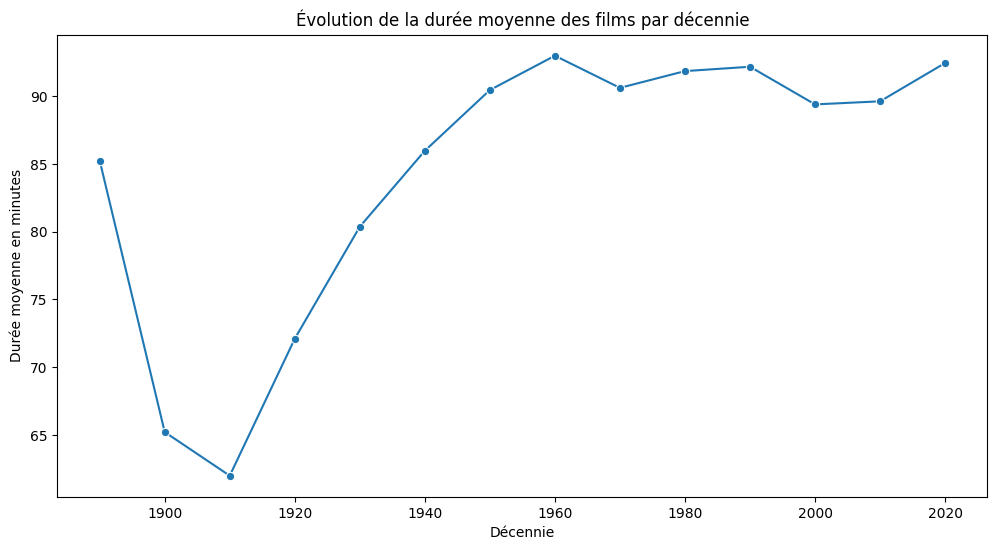

  genres_final  proportion
0        Drama   26.599117
1  Documentary   14.418451
2       Comedy   12.114193
3       Action    6.023033
4      Romance    5.241516
5     Thriller    5.215920
6       Horror    4.566083
7        Crime    4.219023
8    Adventure    3.111955
9      Mystery    1.990970


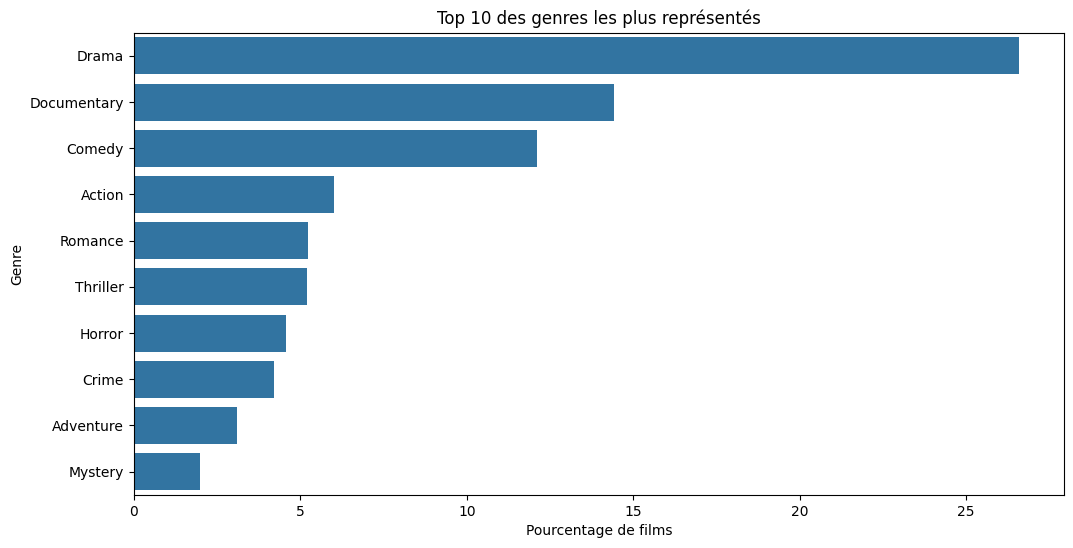

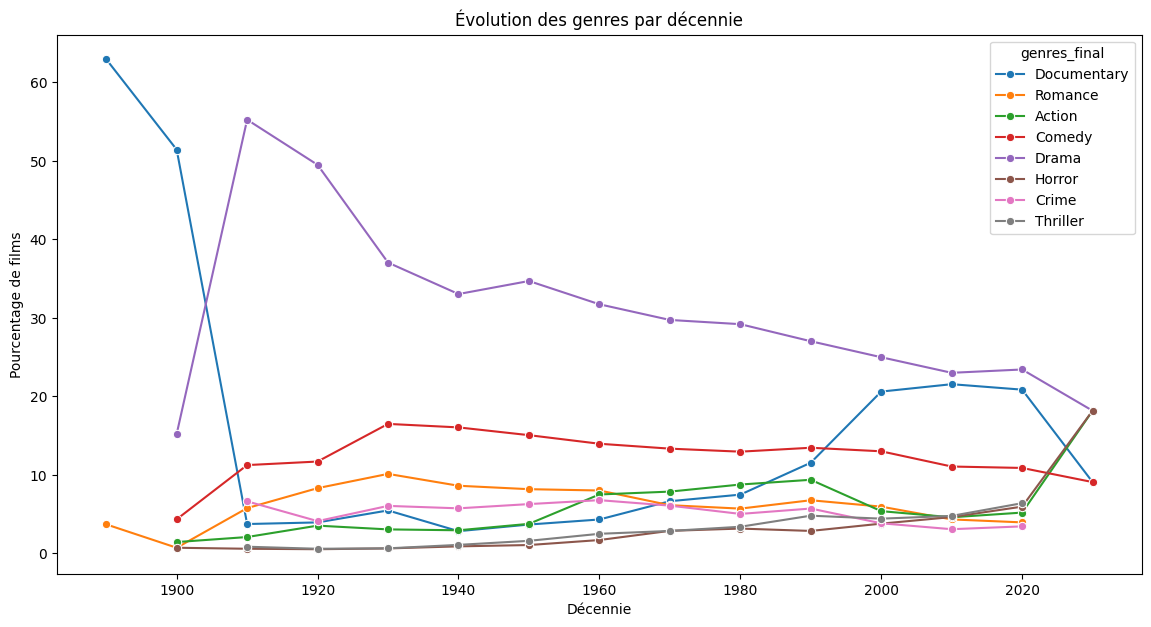

   genres_final        roi
13      Romance  18.880641
10       Horror  16.640993
16     Thriller  14.521198
8       Fantasy  12.345768
2     Animation  12.167935
5         Crime   7.937167
14       Sci-Fi   7.804897
6         Drama   7.694263
1     Adventure   7.396399
9       History   5.462600


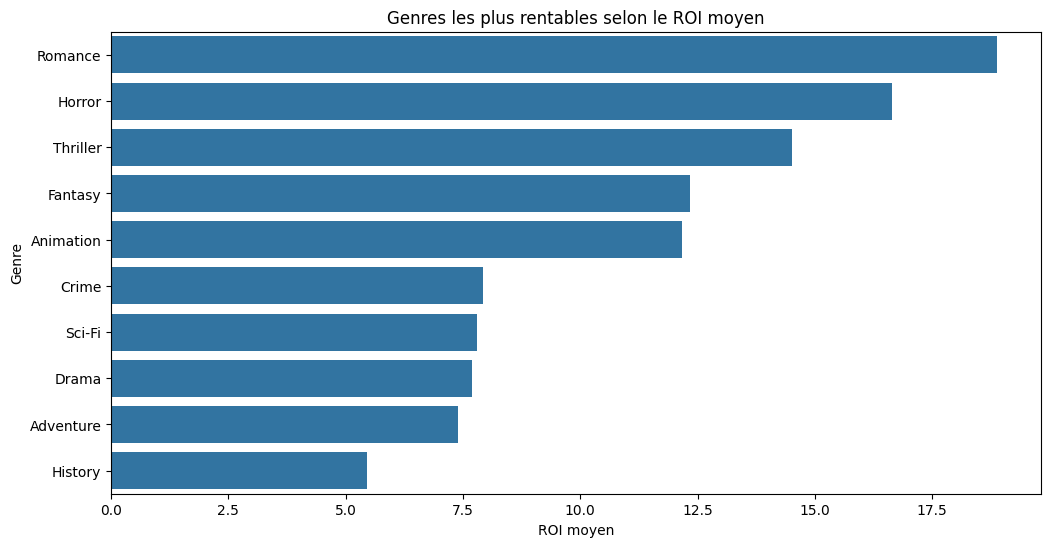

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
movies = pd.read_csv("movies_final.csv")

#--------------------------------------------------------------------------------------------
# KPI 1 - EVOLUTION DUREE DES FILMS PAR DECENNIE
#--------------------------------------------------------------------------------------------
runtime_decennie = movies.groupby("decennie")["runtime_final"].mean().reset_index()
print(runtime_decennie.head())

#Graphique 1
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=runtime_decennie,
    x="decennie",
    y="runtime_final",
    marker="o"
)
plt.title("Évolution de la durée moyenne des films par décennie")
plt.xlabel("Décennie")
plt.ylabel("Durée moyenne en minutes")
plt.show()

#--------------------------------------------------------------------------------------------
# KPI 2 - TOP DES GENRES LES PLUS REPRESENTES
#--------------------------------------------------------------------------------------------

movies_genres = movies.copy()
movies_genres["genres_final"] = movies_genres["genres_final"].str.split(",")
movies_genres = movies_genres.explode("genres_final")
kpi_genres = movies_genres["genres_final"].value_counts(normalize=True) * 100
kpi_genres = kpi_genres.reset_index()
print(kpi_genres.head(10))

#Graphique 2
plt.figure(figsize=(12, 6))
sns.barplot(
    data=kpi_genres.head(10),
    x="proportion",
    y="genres_final"
)
plt.title("Top 10 des genres les plus représentés")
plt.xlabel("Pourcentage de films")
plt.ylabel("Genre")
plt.show()

#--------------------------------------------------------------------------------------------
# KPI 3 - REPARTITION DES FILMS PAR GENRE AU COURS DU TEMPS
#--------------------------------------------------------------------------------------------
genre_decennie = movies_genres.groupby(
    ["decennie", "genres_final"]
).size().reset_index(name="nb_films")
genre_decennie["total_decennie"] = genre_decennie.groupby("decennie")["nb_films"].transform("sum")
genre_decennie["pourcentage"] = (
    genre_decennie["nb_films"] / genre_decennie["total_decennie"]
) * 100
top_genres = movies_genres["genres_final"].value_counts().head(8).index

genre_decennie_top = genre_decennie[
    genre_decennie["genres_final"].isin(top_genres)
]

#Graphique 3
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=genre_decennie_top,
    x="decennie",
    y="pourcentage",
    hue="genres_final",
    marker="o"
)
plt.title("Évolution des genres par décennie")
plt.xlabel("Décennie")
plt.ylabel("Pourcentage de films")
plt.show()

#--------------------------------------------------------------------------------------------
# KPI 4 - RENTABILITE PAR BUGDET ET REVENU
#--------------------------------------------------------------------------------------------
profit = movies_genres.dropna(
    subset=["budget_tmdb", "revenue_tmdb", "genres_final"]
)
profit = profit[
    (profit["budget_tmdb"] > 0) &
    (profit["revenue_tmdb"] > 0)
]
profit["roi"] = (
    profit["revenue_tmdb"] - profit["budget_tmdb"]
) / profit["budget_tmdb"]
rentabilite_genre = profit.groupby("genres_final")["roi"].mean().reset_index()
rentabilite_genre = rentabilite_genre.sort_values(
    by="roi",
    ascending=False
)
print(rentabilite_genre.head(10))

#Graphique 4
plt.figure(figsize=(12, 6))
sns.barplot(
    data=rentabilite_genre.head(10),
    x="roi",
    y="genres_final"
)
plt.title("Genres les plus rentables selon le ROI moyen")
plt.xlabel("ROI moyen")
plt.ylabel("Genre")
plt.show()

In [12]:

movies = pd.read_csv("movies_final.csv")

#--------------------------------------------------------------------------------------------
# KPI 1 - EVOLUTION DUREE DES FILMS PAR DECENNIE
#--------------------------------------------------------------------------------------------
runtime_decennie = movies.groupby("decennie")["runtime_final"].mean().reset_index()
print(runtime_decennie.head())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
movies = pd.read_csv("movies_final.csv")

#--------------------------------------------------------------------------------------------
# KPI 1 - EVOLUTION DUREE DES FILMS PAR DECENNIE
#--------------------------------------------------------------------------------------------
runtime_decennie = (
    movies.groupby("decennie")["runtime_final"]
    .mean()
    .reset_index()
)

fig = px.line(
    runtime_decennie,
    x="decennie",
    y="runtime_final",
    markers=True,
    title="Évolution de la durée moyenne des films par décennie",
    labels={
        "decennie": "Décennie",
        "runtime_final": "Durée moyenne (min)"
    },
    color_discrete_sequence=px.colors.sequential.Viridis
)

fig.update_layout(
    height=600,
    title_font_size=22
)

# 🔥 Enlever le quadrillage
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True)

fig.show()

fig.write_image("plots/EVOL_DUREE_FILMS_DECENNIE.png")


   decennie  runtime_final
0    1890.0      85.250000
1    1900.0      65.217391
2    1910.0      61.996186
3    1920.0      72.103475
4    1930.0      80.368122


Resorting to unclean kill browser.


#--------------------------------------------------------------------------------------------
# KPI 1 - GRAPHIQUE DYNAMIQUE LOU-ANNE
#--------------------------------------------------------------------------------------------


In [13]:
#--------------------------------------------------------------------------------------------
# KPI 1 - EVOLUTION DUREE DES FILMS PAR DECENNIE
#--------------------------------------------------------------------------------------------

# Préparer top genres
movies_tmp = movies.copy()
movies_tmp["genres_final"] = movies_tmp["genres_final"].str.split(",")
movies_tmp = movies_tmp.explode("genres_final")
top_genres = movies_tmp["genres_final"].value_counts().head(6).index.tolist()

df = (movies_tmp[movies_tmp["genres_final"].isin(top_genres)]
      .groupby(["decennie", "genres_final"])["runtime_final"]
      .mean()
      .reset_index())
df["decennie_num"] = pd.to_numeric(df["decennie"], errors="coerce")

fig = px.line(
    df.sort_values("decennie_num"),
    x="decennie_num",
    y="runtime_final",
    color="genres_final",
    facet_col="genres_final",
    facet_col_wrap=3,
    markers=True,
    title="Durée moyenne par décennie pour les principaux genres",
    labels={"decennie_num":"Décennie", "runtime_final":"Durée (min)"}
)
fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)
fig.update_layout(height=700, title_font_size=18, margin=dict(t=100, l=60, r=40, b=60), showlegend=False)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # nettoie les titres de facets
fig.show()


In [15]:
#--------------------------------------------------------------------------------------------
# KPI 1 - EVOLUTION DUREE DES FILMS PAR DECENNIE
#--------------------------------------------------------------------------------------------



import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# Lecture et préparation
movies = pd.read_csv("movies_final.csv")
movies_tmp = movies.copy()
movies_tmp["genres_final"] = movies_tmp["genres_final"].str.split(",")
movies_tmp = movies_tmp.explode("genres_final").reset_index(drop=True)

# Liste complète des genres triée par fréquence
genre_counts = movies_tmp["genres_final"].value_counts()
all_genres = genre_counts.index.tolist()

# Widget multi-sélection + bouton "Tous"
select = widgets.SelectMultiple(
    options=all_genres,
    value=tuple(genre_counts.head(6).index),  # sélection par défaut : top 6
    rows=8,
    description="Genres",
    layout=widgets.Layout(width="40%")
)
btn_all = widgets.Button(description="Tous", button_style="primary")
btn_clear = widgets.Button(description="Effacer", button_style="warning")

# comportement des boutons
def on_all_clicked(b):
    select.value = tuple(all_genres)

def on_clear_clicked(b):
    select.value = tuple()

btn_all.on_click(on_all_clicked)
btn_clear.on_click(on_clear_clicked)

controls = widgets.HBox([select, widgets.VBox([btn_all, btn_clear])])
display(controls)

# Fonction de tracé
def plot_small_multiples(selected_genres, facet_wrap=3, max_genres_display=20):
    if not selected_genres:
        print("Aucun genre sélectionné.")
        return

    # Si "Tous" (ou sélection complète) et trop de genres, limiter aux top N pour lisibilité
    selected = list(selected_genres)
    if len(selected) > max_genres_display:
        top_n = genre_counts.loc[selected].sort_values(ascending=False).head(max_genres_display).index.tolist()
        selected = top_n

    df = (
        movies_tmp[movies_tmp["genres_final"].isin(selected)]
        .groupby(["decennie", "genres_final"])["runtime_final"]
        .mean()
        .reset_index()
    )
    df["decennie_num"] = pd.to_numeric(df["decennie"], errors="coerce")
    df = df.sort_values(["genres_final", "decennie_num"])

    # small multiples
    fig = px.line(
        df,
        x="decennie_num",
        y="runtime_final",
        color="genres_final",
        facet_col="genres_final",
        facet_col_wrap=facet_wrap,
        markers=True,
        title=f"Durée moyenne par décennie — {len(selected)} genre(s) affiché(s)",
        labels={"decennie_num": "Décennie", "runtime_final": "Durée (min)"},
        color_discrete_sequence=px.colors.sequential.Viridis
    )

    # style épuré
    fig.update_xaxes(showgrid=True)
    fig.update_yaxes(showgrid=True)
    fig.update_layout(height=300 + 220 * ((len(selected) - 1) // facet_wrap + 1),
                      margin=dict(t=90, l=60, r=40, b=60),
                      showlegend=False,
                      title_font_size=)

    # nettoyer les titres de facets (supprime "genres_final=")
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

    fig.update_traces(mode="lines+markers", marker=dict(size=6))
    fig.show()

# Liaison widget -> plot
out = widgets.interactive_output(plot_small_multiples, {"selected_genres": select})
display(out)


SyntaxError: expected argument value expression (1074667327.py, line 87)

In [16]:

#--------------------------------------------------------------------------------------------
# KPI 2 - TOP DES GENRES LES PLUS REPRESENTES
#--------------------------------------------------------------------------------------------

import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# Préparation (conserve ton code)
movies_genres = movies.copy()
movies_genres["genres_final"] = movies_genres["genres_final"].str.split(",")
movies_genres = movies_genres.explode("genres_final")

# Valeurs en % avec noms de colonnes uniques
kpi_genres = (
    movies_genres["genres_final"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("genres_final")
    .reset_index(name="Pourcentage")
)

# Tri une fois pour toutes
kpi_genres = kpi_genres.sort_values("Pourcentage", ascending=False).reset_index(drop=True)

# Fonction d'affichage
def plot_top_genres(top_n=10):
    df = kpi_genres.head(top_n).sort_values("Pourcentage", ascending=True)
    fig = px.bar(
        df,
        x="Pourcentage",
        y="genres_final",
        orientation="h",
        color="Pourcentage",
        color_continuous_scale=px.colors.sequential.Viridis,
        labels={"genres_final": "Genre", "Pourcentage": "Pourcentage (%)"},
        title=f"Top {top_n} des genres les plus représentés",
        height=520
    )
    fig.update_layout(margin=dict(l=160, r=40, t=70, b=40), title_font_size=18, showlegend=False)
    fig.update_xaxes(showgrid=True, tickformat=".1f")
    fig.update_yaxes(showgrid=False, automargin=True)
    fig.update_traces(hovertemplate="<b>%{y}</b><br>Pourcentage: %{x:.2f}%<extra></extra>")
    fig.show()

# Widget Top N
top_slider = widgets.IntSlider(value=10, min=3, max=min(30, len(kpi_genres)), step=1, description="Top N")
out = widgets.interactive_output(plot_top_genres, {"top_n": top_slider})
display(widgets.HBox([top_slider]), out)



Output()

In [17]:

# ------------------------------------------------------------
# KPI 3 - REPARTITION DES FILMS PAR GENRE AU COURS DU TEMPS
# ------------------------------------------------------------

import numpy as np
import plotly.express as px


# --- Préparation (conserve ton code) ---
genre_decennie = movies_genres.groupby(
    ["decennie", "genres_final"]
).size().reset_index(name="nb_films")

genre_decennie["total_decennie"] = genre_decennie.groupby("decennie")["nb_films"].transform("sum")
genre_decennie["pourcentage"] = (genre_decennie["nb_films"] / genre_decennie["total_decennie"]) * 100

top_genres = movies_genres["genres_final"].value_counts().head(8).index
genre_decennie_top = genre_decennie[genre_decennie["genres_final"].isin(top_genres)].copy()

# convertir la décénnie en numérique pour le range slider
genre_decennie_top["decennie_num"] = pd.to_numeric(genre_decennie_top["decennie"], errors="coerce")

# --- Palette ordonnée pour les genres
unique_genres = sorted(genre_decennie_top["genres_final"].unique())
viridis = px.colors.sequential.Viridis
palette = [viridis[int(i)] for i in np.linspace(0, len(viridis) - 1, len(unique_genres))]
color_map = {g: palette[i] for i, g in enumerate(unique_genres)}

# --- Figure principale
fig = px.line(
    genre_decennie_top,
    x="decennie_num",
    y="pourcentage",
    color="genres_final",
    markers=True,
    labels={"decennie_num": "Décennie", "pourcentage": "Pourcentage (%)", "genres_final": "Genre"},
    color_discrete_map=color_map,
    title="Évolution des genres par décennie",
    height=600
)

# range slider et ticks
decades = sorted(genre_decennie_top["decennie_num"].dropna().unique())
fig.update_xaxes(rangeslider_visible=True, tickmode="array", tickvals=decades, ticktext=[str(int(d)) for d in decades])

# supprimer quadrillage
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True)

# dropdown simple: Tous + chaque genre
buttons = [{"label": "Tous", "method": "update", "args": [{"visible": [True] * len(unique_genres)}, {"title": "Évolution des genres par décennie — Tous"}]}]
for i, g in enumerate(unique_genres):
    vis = [False] * len(unique_genres)
    vis[i] = True
    buttons.append({"label": g, "method": "update", "args": [{"visible": vis}, {"title": f"Évolution du genre — {g}"}]})

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0, y=1.12, xanchor="left", yanchor="top", direction="down")],
    legend_title_text="Genre",
    margin=dict(t=120),
    title_font_size=18
)

fig.update_traces(mode="lines+markers", marker=dict(size=7))
fig.show()

fig.write_image("plots/REPARTITION_FILMS_GENRE_TIMELAPS.png")


In [18]:

#--------------------------------------------------------------------------------------------
# KPI 4 - RENTABILITE PAR BUGDET ET REVENU
#--------------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# --- Préparation (conserve ton code) ---
profit = movies_genres.dropna(subset=["budget_tmdb", "revenue_tmdb", "genres_final"]).copy()
profit = profit[(profit["budget_tmdb"] > 0) & (profit["revenue_tmdb"] > 0)]
profit["roi"] = (profit["revenue_tmdb"] - profit["budget_tmdb"]) / profit["budget_tmdb"]

rentabilite_genre = (
    profit.groupby("genres_final")["roi"]
    .mean()
    .reset_index()
    .sort_values(by="roi", ascending=False)
)

# Fonction qui construit et affiche la figure selon top_n et ordre
def plot_roi_top(top_n=10, ascending=False):
    df = rentabilite_genre.copy()
    df = df.head(top_n) if not ascending else df.sort_values("roi", ascending=True).head(top_n)
    df = df.sort_values("roi", ascending=True)  # pour bar horizontale du plus petit en haut au plus grand en bas

    fig = px.bar(
        df,
        x="roi",
        y="genres_final",
        orientation="h",
        color="roi",
        color_continuous_scale=px.colors.sequential.Viridis,
        labels={"roi": "ROI moyen", "genres_final": "Genre"},
        title=f"Top {top_n} Genres par ROI moyen",
        height=520
    )

    # style épuré
    fig.update_layout(margin=dict(l=160, r=40, t=70, b=40), title_font_size=18)
    fig.update_xaxes(showgrid=False, tickformat=".2f")
    fig.update_yaxes(showgrid=False, automargin=True)
    fig.update_traces(hovertemplate="<b>%{y}</b><br>ROI moyen: %{x:.2f}<extra></extra>")

    fig.show()

# Widgets pour interactivité
top_slider = widgets.IntSlider(value=10, min=3, max=min(30, len(rentabilite_genre)), step=1, description="Top N")
order_toggle = widgets.ToggleButtons(options=[("Décroissant", False), ("Croissant", True)], description="Ordre")

ui = widgets.HBox([top_slider, order_toggle])
out = widgets.interactive_output(plot_roi_top, {"top_n": top_slider, "ascending": order_toggle})

display(ui, out)

fig.write_image("plots/RENT_ROI.png")


Output()

#--------------------------------------------------------------------------------------------
# KPI 1 - GRAPHIQUE DYNAMIQUE KATARINA
#--------------------------------------------------------------------------------------------


In [92]:
path = "df_clean.parquet" if os.path.exists("df_clean.parquet") else "imdb_base.parquet"
df = pd.read_parquet(path)

df.head()

,imdb_id,original_title_imdb,year,runtime_imdb,genres_imdb,genres_imdb_list,imdb_rating,imdb_votes,directors_names,writers_names,...,tmdb_id,backdrop_path,budget,overview,tmdb_popularity,poster_path,status,production_companies_name,production_companies_country,revenue
0,tt0111161,The Shawshank Redemption,1994.0,142.0,Drama,[Drama],9.3,3191478,[Frank Darabont],"[Stephen King, Frank Darabont]",...,278,/zfbjgQE1uSd9wiPTX4VzsLi0rGG.jpg,25000000,Imprisoned in the 1940s for the double murder ...,65.3308,/9cqNxx0GxF0bflZmeSMuL5tnGzr.jpg,Released,[Castle Rock Entertainment],[US],28341469
1,tt0468569,The Dark Knight,2008.0,152.0,"Crime,Thriller","[Crime, Thriller]",9.1,3170871,[Christopher Nolan],"[Jonathan Nolan, Christopher Nolan, David S. G...",...,155,/cfT29Im5VDvjE0RpyKOSdCKZal7.jpg,185000000,Batman raises the stakes in his war on crime. ...,45.5176,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Released,"[Warner Bros. Pictures, Legendary Pictures, Sy...","[US, US, GB, US]",1004558444
2,tt1375666,Inception,2010.0,148.0,"Adventure,Sci-Fi,Thriller","[Adventure, Sci-Fi, Thriller]",8.8,2819793,[Christopher Nolan],[Christopher Nolan],...,27205,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,"Cobb, a skilled thief who commits corporate es...",38.5801,/xlaY2zyzMfkhk0HSC5VUwzoZPU1.jpg,Released,"[Legendary Pictures, Syncopy, Warner Bros. Pic...","[US, GB, US]",839030630
3,tt0137523,Fight Club,1999.0,139.0,"Crime,Drama,Thriller","[Crime, Drama, Thriller]",8.8,2611578,[David Fincher],"[Chuck Palahniuk, Jim Uhls]",...,550,/xRyINp9KfMLVjRiO5nCsoRDdvvF.jpg,63000000,A ticking-time-bomb insomniac and a slippery s...,28.8902,/jSziioSwPVrOy9Yow3XhWIBDjq1.jpg,Released,"[Fox 2000 Pictures, Regency Enterprises, Linso...","[US, US, US, US, DE]",100853753
4,tt0816692,Interstellar,2014.0,169.0,"Adventure,Drama,Sci-Fi","[Adventure, Drama, Sci-Fi]",8.7,2533044,[Christopher Nolan],"[Jonathan Nolan, Christopher Nolan]",...,157336,/2ssWTSVklAEc98frZUQhgtGHx7s.jpg,165000000,The adventures of a group of explorers who mak...,75.1374,/yQvGrMoipbRoddT0ZR8tPoR7NfX.jpg,Released,"[Legendary Pictures, Syncopy, Lynda Obst Produ...","[US, GB, US]",746606706


In [89]:
import pandas as pd
import numpy as np
import plotly.express as px
import os
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# 1) Chargement du fichier
# ------------------------------------------------------------
path = "df_clean.parquet" if os.path.exists("df_clean.parquet") else "imdb_base.parquet"
df = pd.read_parquet(path)

# ------------------------------------------------------------
# 2) Fonctions robustes de parsing
# ------------------------------------------------------------
def parse_list_safe(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return [str(i).strip() for i in x if str(i).strip()]
    if isinstance(x, (list, tuple, set)):
        return [str(i).strip() for i in x if str(i).strip()]
    s = str(x)
    s = s.replace(" / ", ",").replace(" | ", ",").replace(";", ",")
    return [p.strip() for p in s.split(",") if p.strip()]

def parse_people_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return [str(i).strip() for i in x if str(i).strip()]
    if isinstance(x, (list, tuple, set)):
        return [str(i).strip() for i in x if str(i).strip()]
    s = str(x)
    s = s.replace(" / ", ",").replace(" | ", ",").replace(";", ",")
    return [p.strip() for p in s.split(",") if p.strip()]

# ------------------------------------------------------------
# 3) Préparation des colonnes
# ------------------------------------------------------------
df["_countries"] = df["production_companies_country"].apply(parse_list_safe)
df["_companies"] = df["production_companies_name"].apply(parse_list_safe)

df["_actors"] = df["actors_names"].apply(parse_people_list)
df["_directors"] = df["directors_names"].apply(parse_people_list)
df["_writers"] = df["writers_names"].apply(parse_people_list)
df["_composers"] = df["composers_names"].apply(parse_people_list)

# ------------------------------------------------------------
# 4) Fonction de tracé Top N
# ------------------------------------------------------------
def plot_topN(df, column, title, N):
    exploded = df.explode(column)
    vc = (
        exploded[column]
        .dropna()
        .value_counts()
        .head(N)
        .reset_index()
    )
    if vc.empty:
        print(f"Aucune donnée pour {title}")
        return

    vc.columns = ["Label", "Count"]

    fig = px.bar(
        vc.sort_values("Count"),
        x="Count",
        y="Label",
        orientation="h",
        color="Count",
        color_continuous_scale=px.colors.sequential.Viridis,
        title=f"{title} — Top {N}"
    )
    fig.update_layout(
        margin=dict(l=220, r=40, t=70, b=60),
        height=550
    )
    fig.show()

# ------------------------------------------------------------
# 5) Menu déroulant + slider Top N
# ------------------------------------------------------------
dropdown = widgets.Dropdown(
    options={
        "Acteurs": "_actors",
        "Réalisateurs": "_directors",
        "Scénaristes": "_writers",
        "Compositeurs": "_composers",
        "Pays": "_countries",
        "Sociétés": "_companies"
    },
    value="_actors",
    description="Famille :",
)

slider_top = widgets.IntSlider(
    value=10,
    min=5,
    max=50,
    step=5,
    description="Top (Qté):",
    continuous_update=False
)

output = widgets.Output()

# ------------------------------------------------------------
# 6) Fonction de mise à jour
# ------------------------------------------------------------
def update_graph(change):
    with output:
        clear_output(wait=True)
        col = dropdown.value
        title = dropdown.label
        N = slider_top.value
        plot_topN(df, col, title, N)

dropdown.observe(update_graph, names="value")
slider_top.observe(update_graph, names="value")

# ------------------------------------------------------------
# 7) Affichage
# ------------------------------------------------------------
display(dropdown, slider_top, output)
update_graph(None)


Dropdown(description='Famille :', options={'Acteurs': '_actors', 'Réalisateurs': '_directors', 'Scénaristes': …

IntSlider(value=10, continuous_update=False, description='Top (Qté):', max=50, min=5, step=5)

Output()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import os
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# 1) Chargement du fichier
# ------------------------------------------------------------
path = "df_clean.parquet" if os.path.exists("df_clean.parquet") else "imdb_base.parquet"
df = pd.read_parquet(path)

# ------------------------------------------------------------
# 2) Nettoyage des colonnes utiles
# ------------------------------------------------------------
df["runtime_imdb"] = pd.to_numeric(df.get("runtime_imdb"), errors="coerce")
df["imdb_rating"] = pd.to_numeric(df.get("imdb_rating"), errors="coerce")

# ------------------------------------------------------------
# 3) Fonction d'affichage histogramme (Viridis premium)
# ------------------------------------------------------------
def plot_histogram(df, column, title, bins):
    clean = df[column].dropna()

    fig = px.histogram(
        clean,
        x=clean,
        nbins=bins,
        color_discrete_sequence=["#3B528B"],  # VIRIDIS PREMIUM (bleu-violet)
        title=f"{title} — {bins} classes"
    )

    fig.update_layout(
        height=500,
        margin=dict(l=60, r=40, t=60, b=60),
        bargap=0.05
    )
    fig.update_xaxes(title=title)
    fig.update_yaxes(title="Fréquence")
    fig.show()

# ------------------------------------------------------------
# 4) Menu déroulant + slider quantité (nbins)
# ------------------------------------------------------------
dropdown_hist = widgets.Dropdown(
    options={
        "Distribution Durée (runtime_imdb)": "runtime_imdb",
        "Distribution Notes IMDb": "imdb_rating"
    },
    value="runtime_imdb",
    description="Variable :",
)

slider_bins = widgets.IntSlider(
    value=30,
    min=10,
    max=100,
    step=5,
    description="Nb classes :",
    continuous_update=False
)

output_hist = widgets.Output()

# ------------------------------------------------------------
# 5) Fonction de mise à jour
# ------------------------------------------------------------
def update_hist(change):
    with output_hist:
        clear_output(wait=True)
        col = dropdown_hist.value
        title = dropdown_hist.label
        bins = slider_bins.value
        plot_histogram(df, col, title, bins)

dropdown_hist.observe(update_hist, names="value")
slider_bins.observe(update_hist, names="value")

# ------------------------------------------------------------
# 6) Affichage
# ------------------------------------------------------------
display(dropdown_hist, slider_bins, output_hist)
update_hist(None)


Dropdown(description='Variable :', options={'Distribution Durée (runtime_imdb)': 'runtime_imdb', 'Distribution…

IntSlider(value=30, continuous_update=False, description='Nb classes :', min=10, step=5)

Output()